   alcohol  malic_acid  Cluster
0    14.23        1.71        1
1    13.20        1.78        1
2    13.16        2.36        2
3    14.37        1.95        2
4    13.24        2.59        1
5    14.20        1.76        2
6    14.39        1.87        2
7    14.06        2.15        2
8    14.83        1.64        1
9    13.86        1.35        1
Clustering Accuracy: 0.69


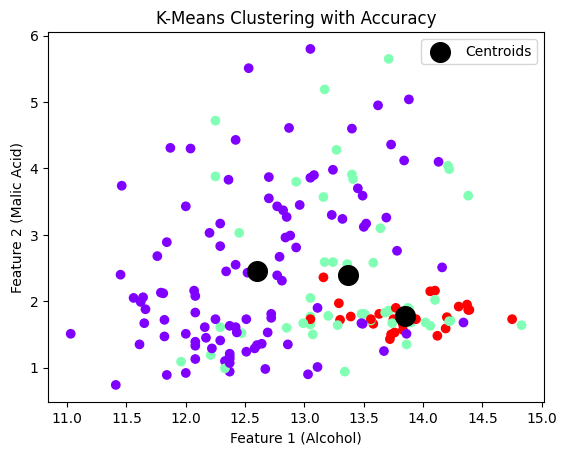

In [4]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
from scipy.stats import mode
import numpy as np

# Load dataset
data = load_wine()
X = data.data
y_true = data.target  # actual labels

# Convert to DataFrame for better view
df = pd.DataFrame(X, columns=data.feature_names)

# Apply K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X)

# Add cluster labels to DataFrame
df['Cluster'] = clusters

# Print first 10 rows with some columns
print(df[['alcohol', 'malic_acid', 'Cluster']].head(10))

# Map cluster labels to actual labels for accuracy
labels = np.zeros_like(clusters)
for i in range(3):
    mask = (clusters == i)
    labels[mask] = mode(y_true[mask])[0]

# Calculate accuracy
accuracy = accuracy_score(y_true, labels)
print("Clustering Accuracy:", round(accuracy, 2))

# Visualization (2 features)
plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap='rainbow')
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=200, c='black', label='Centroids')
plt.xlabel("Feature 1 (Alcohol)")
plt.ylabel("Feature 2 (Malic Acid)")
plt.title("K-Means Clustering with Accuracy")
plt.legend()
plt.show()